In [1]:
#1) Loading the Taxis Dataset

import seaborn as sns

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
print(df.head())


               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [2]:
#1. Check for Missing Values
# Count missing values per column
print(df.isnull().sum())

# Quick overview of missing data
print(df.info())


pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   obje

In [6]:
#2. Impute Missing Values

# For numerical columns (e.g., 'fare', 'tip', 'distance')
df['fare'] = df['fare'].fillna(df['fare'].median())
df['tip'] = df['tip'].fillna(df['tip'].mean())
df['distance'] = df['distance'].fillna(df['distance'].median())



In [7]:


# For categorical columns (e.g., 'pickup_zone', 'dropoff_zone', 'payment')
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])


In [8]:
# Drop rows where critical columns are missing
df = df.dropna(subset=['pickup', 'dropoff'])


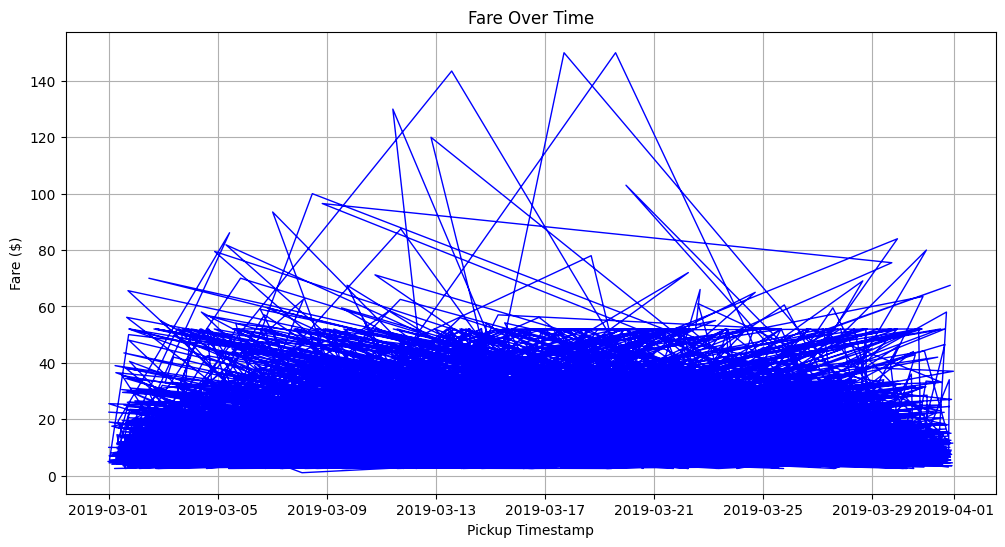

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure pickup column is datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Plot fare over time
plt.figure(figsize=(12,6))
plt.plot(df['pickup'], df['fare'], color='blue', linewidth=1)

plt.title("Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare ($)")
plt.grid(True)
plt.show()


/tmp/ipykernel_713/3336321850.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fare_by_borough.index, y=fare_by_borough.values, palette="viridis")


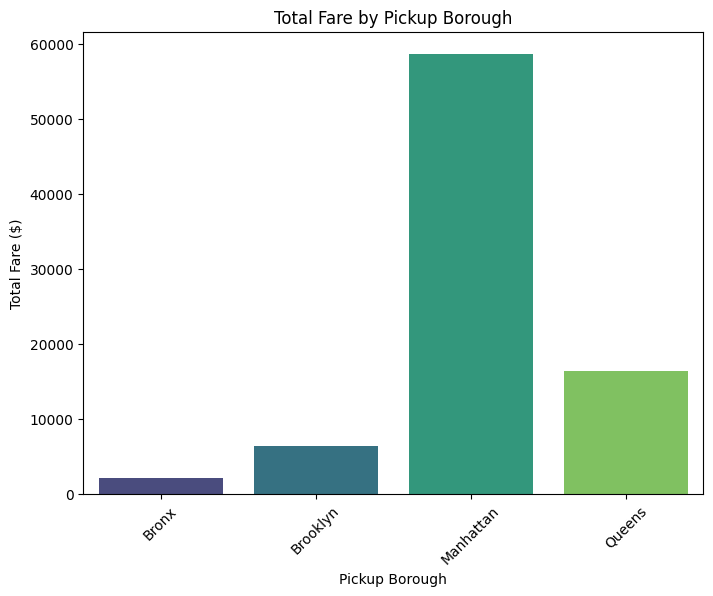

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by pickup_borough and sum the fare
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()

# Plot bar chart
plt.figure(figsize=(8,6))
sns.barplot(x=fare_by_borough.index, y=fare_by_borough.values, palette="viridis")

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=45)
plt.show()


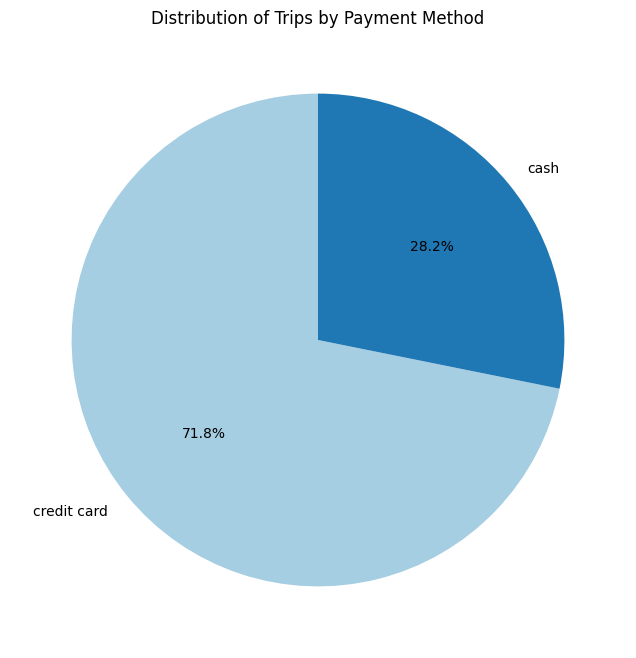

In [17]:
import matplotlib.pyplot as plt

# Count trips by payment method
payment_counts = df['payment'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Paired.colors)

plt.title("Distribution of Trips by Payment Method")
plt.show()


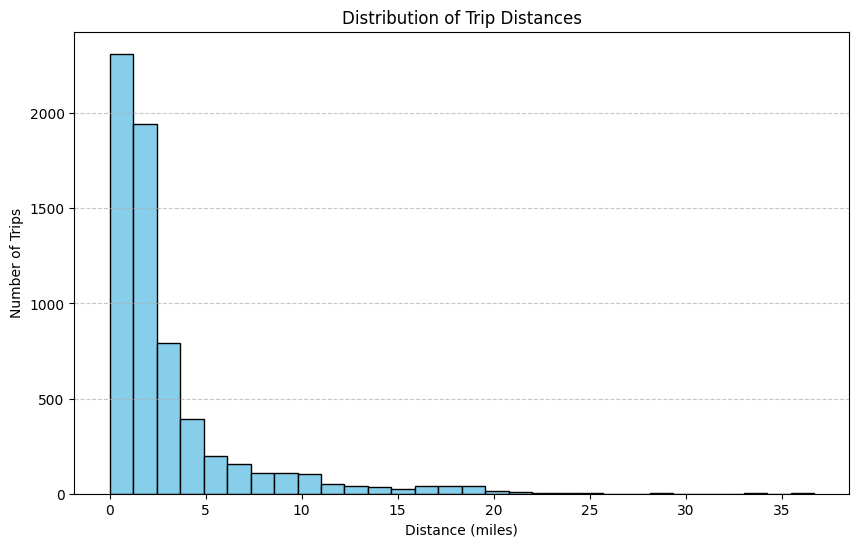

In [18]:
import matplotlib.pyplot as plt

# Plot histogram of distance
plt.figure(figsize=(10,6))
plt.hist(df['distance'], bins=30, color='skyblue', edgecolor='black')

plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Trips")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipykernel_713/4183235232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pickup_borough', y='tip', data=df, palette="Set2")


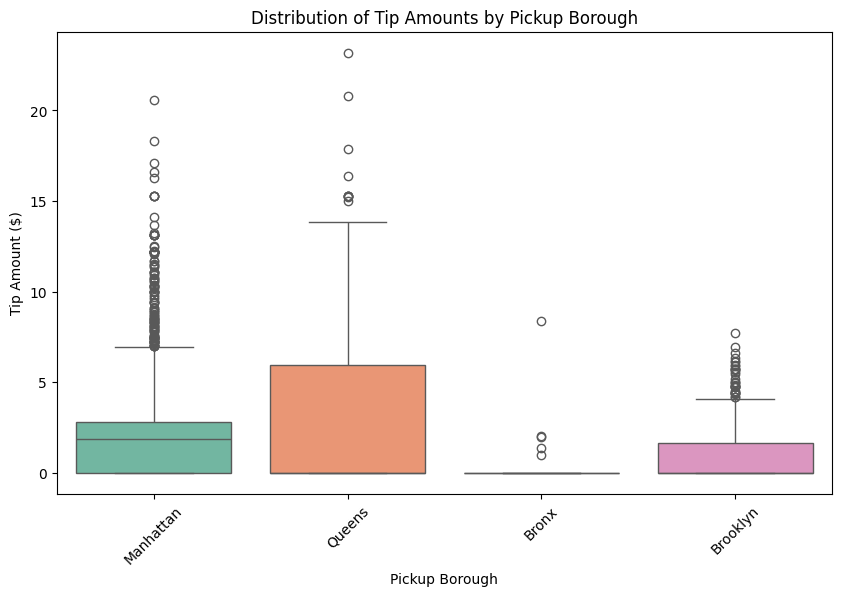

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='pickup_borough', y='tip', data=df, palette="Set2")

plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount ($)")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_713/458871907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_borough', data=df, palette="pastel")


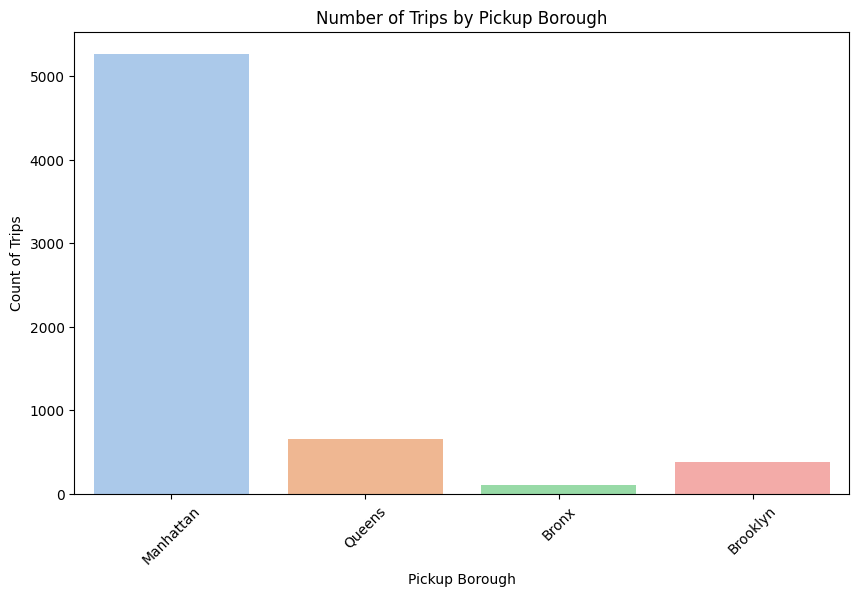

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(x='pickup_borough', data=df, palette="pastel")

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Count of Trips")
plt.xticks(rotation=45)
plt.show()


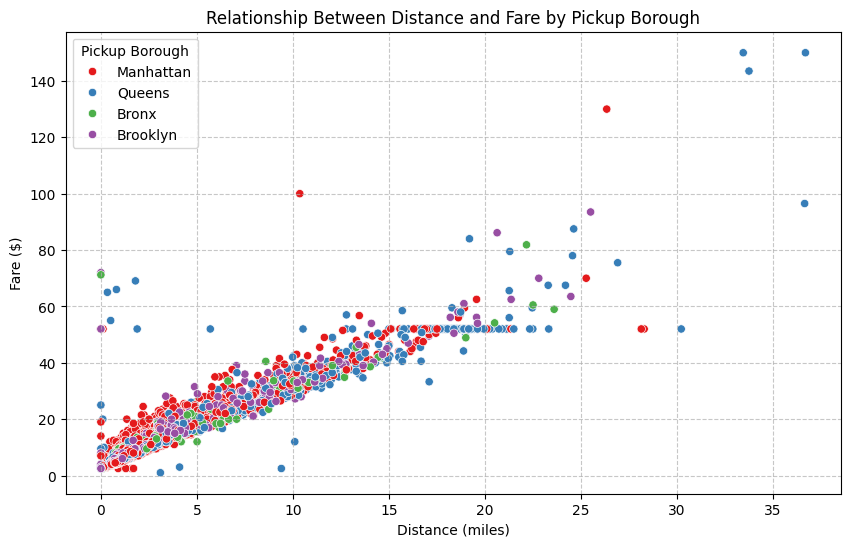

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='distance', y='fare', data=df, hue='pickup_borough', palette="Set1")

plt.title("Relationship Between Distance and Fare by Pickup Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


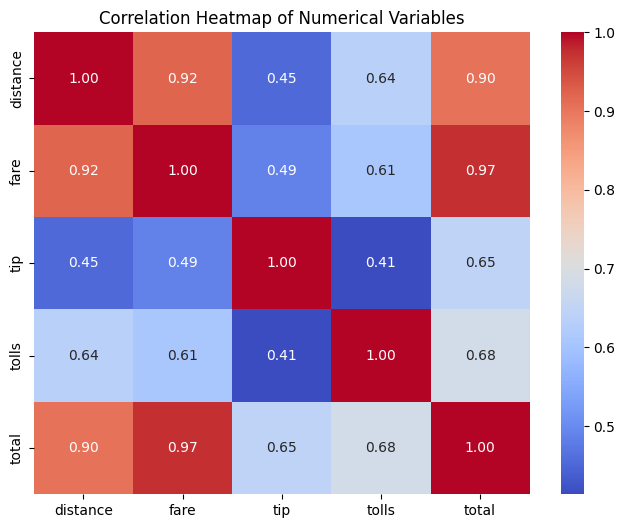

In [22]:
# Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = ['distance', 'fare', 'tip', 'tolls', 'total']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


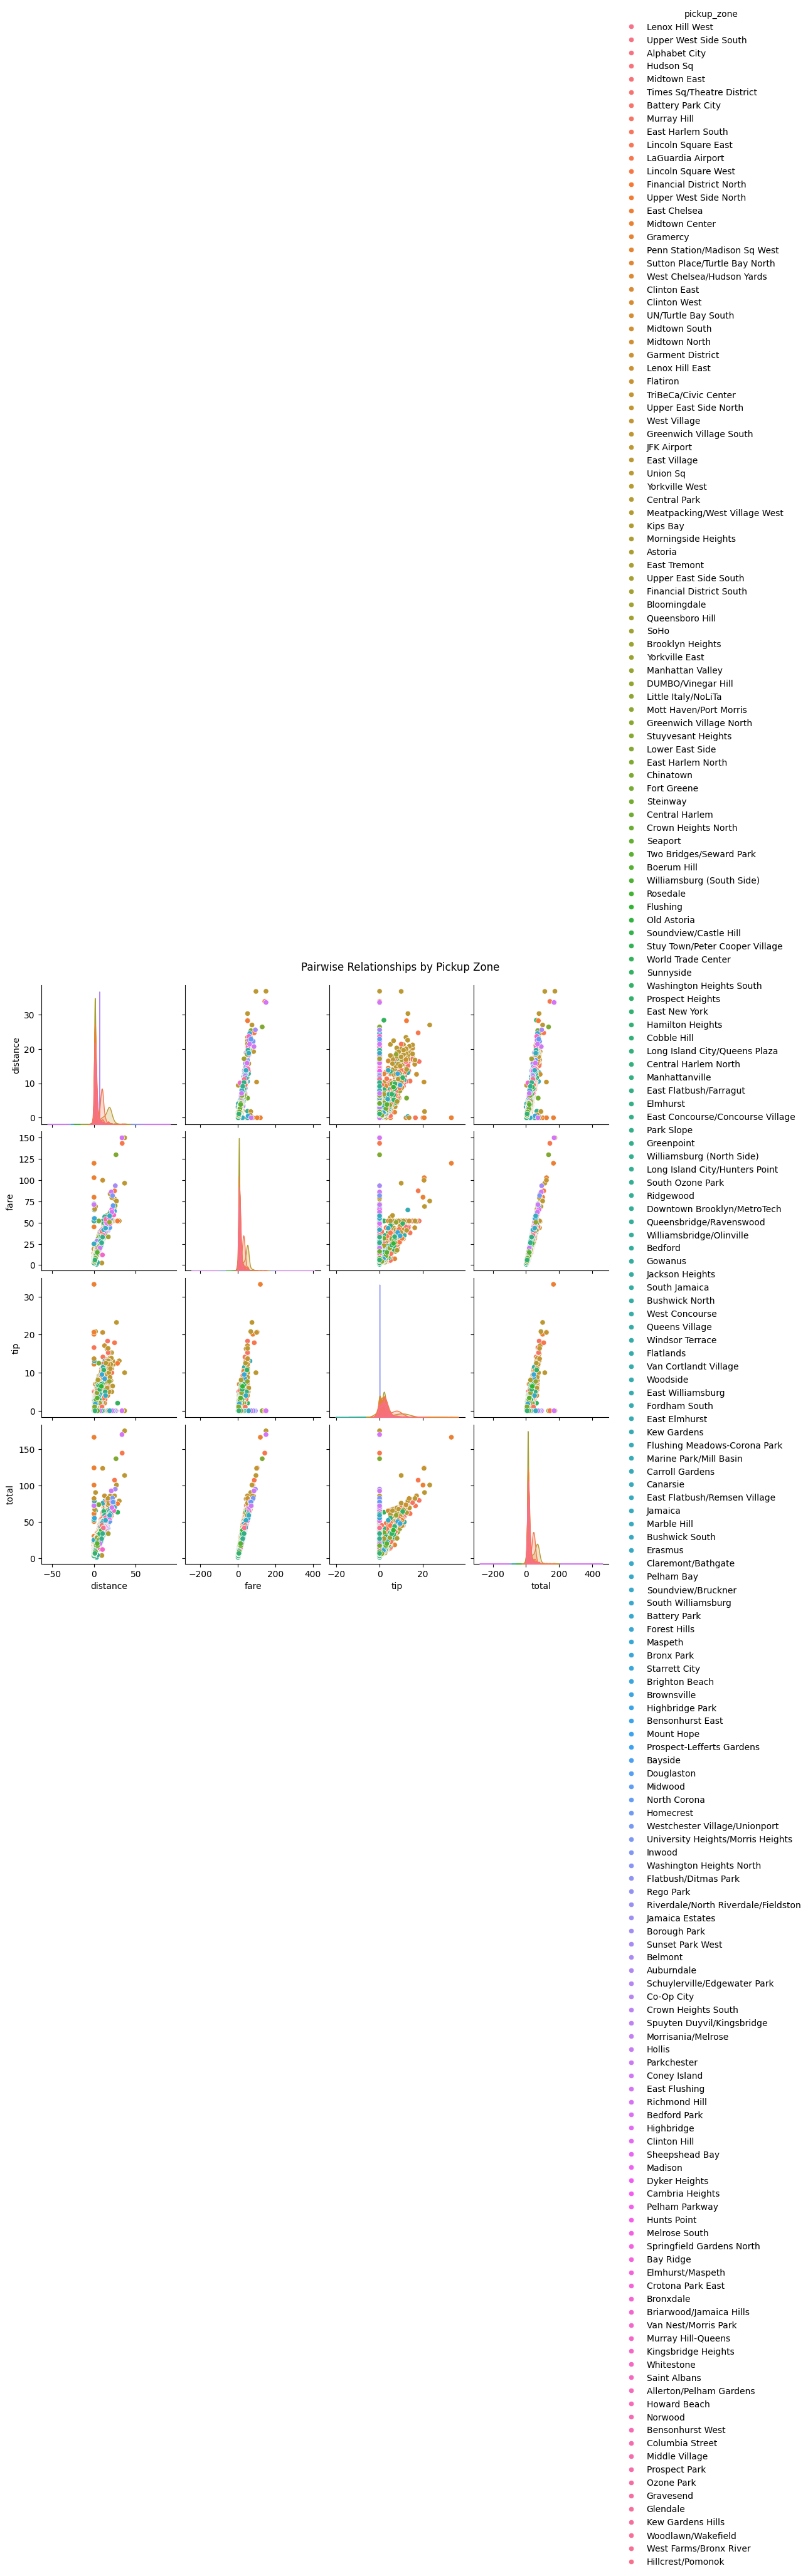

In [23]:
#Pair Plot
sns.pairplot(df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
             hue='pickup_zone', palette="husl")

plt.suptitle("Pairwise Relationships by Pickup Zone", y=1.02)
plt.show()


/tmp/ipykernel_713/2698846873.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='payment', y='fare', data=df, palette="muted")


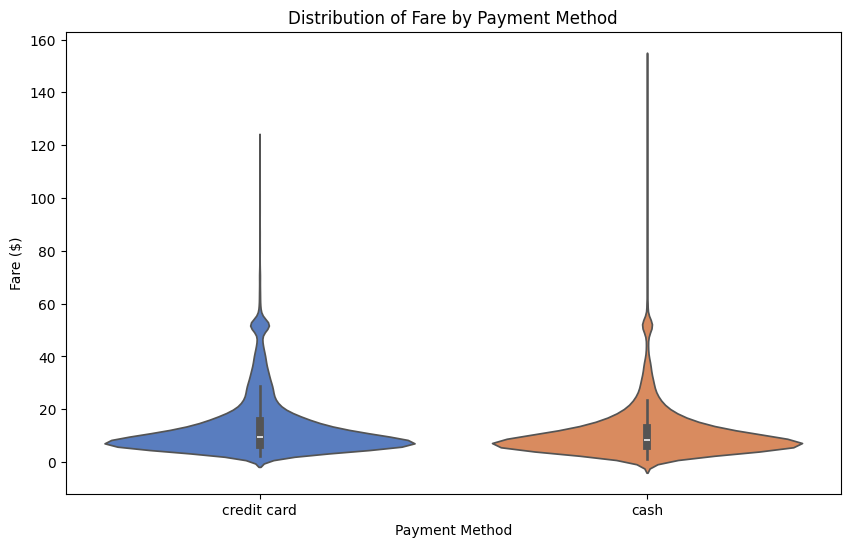

In [24]:
#Violin Plot

plt.figure(figsize=(10,6))
sns.violinplot(x='payment', y='fare', data=df, palette="muted")

plt.title("Distribution of Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.show()
